# A06 Brain Tumor SVC

|                |   |
:----------------|---|
| **Nombre**     David Alejandro Rangel Rodríguez|   |
| **Fecha**     6 de abril del 2026 |   |
| **Expediente*756203* |   |

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data = pd.read_csv('brain_tumor_dataset.csv')
data.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

In [3]:
data.describe()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,49.433700,5.236552,70.131699,1.547701
std,5773.647028,17.389296,2.754359,17.270834,0.835995
min,1.000000,20.000000,0.500410,40.002386,0.100017
25%,5000.750000,34.000000,2.836686,55.224439,0.830433
50%,10000.500000,49.000000,5.200675,70.305066,1.541821
75%,15000.250000,65.000000,7.624299,85.043395,2.262484
max,20000.000000,79.000000,9.999420,99.998125,2.999835


In [4]:
data.isnull().sum()

Patient_ID             0
Age                    0
Gender                 0
Tumor_Type             0
Tumor_Size             0
Location               0
Histology              0
Stage                  0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Radiation_Treatment    0
Surgery_Performed      0
Chemotherapy           0
Survival_Rate          0
Tumor_Growth_Rate      0
Family_History         0
MRI_Result             0
Follow_Up_Required     0
dtype: int64

array([[<Axes: title={'center': 'Patient_ID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Tumor_Size'}>,
        <Axes: title={'center': 'Survival_Rate'}>],
       [<Axes: title={'center': 'Tumor_Growth_Rate'}>, <Axes: >]],
      dtype=object)

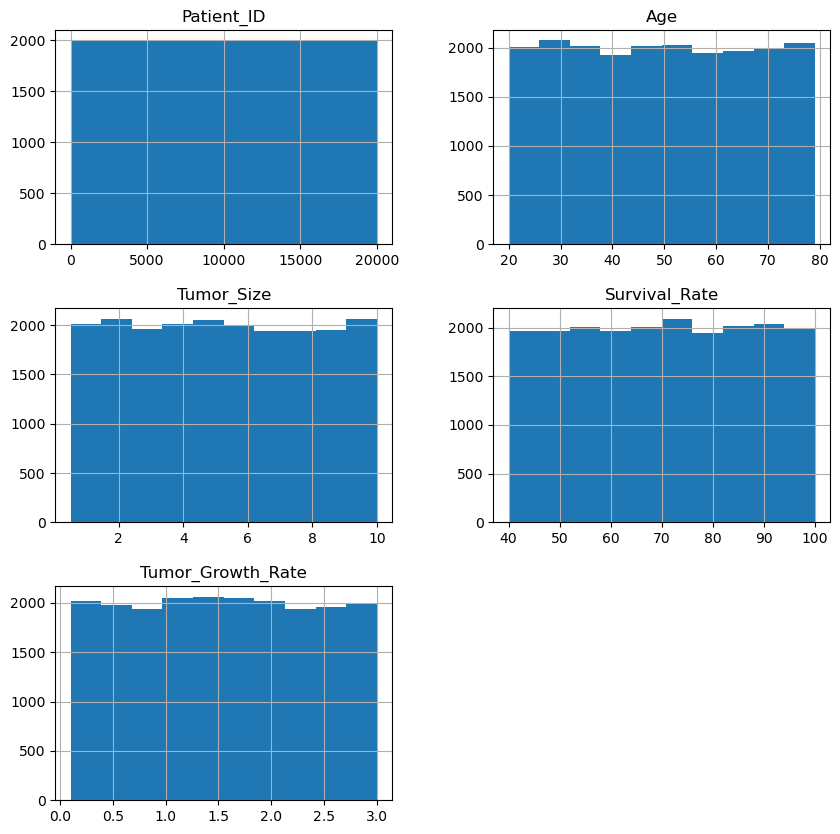

In [6]:
data.hist(figsize=(10,10))

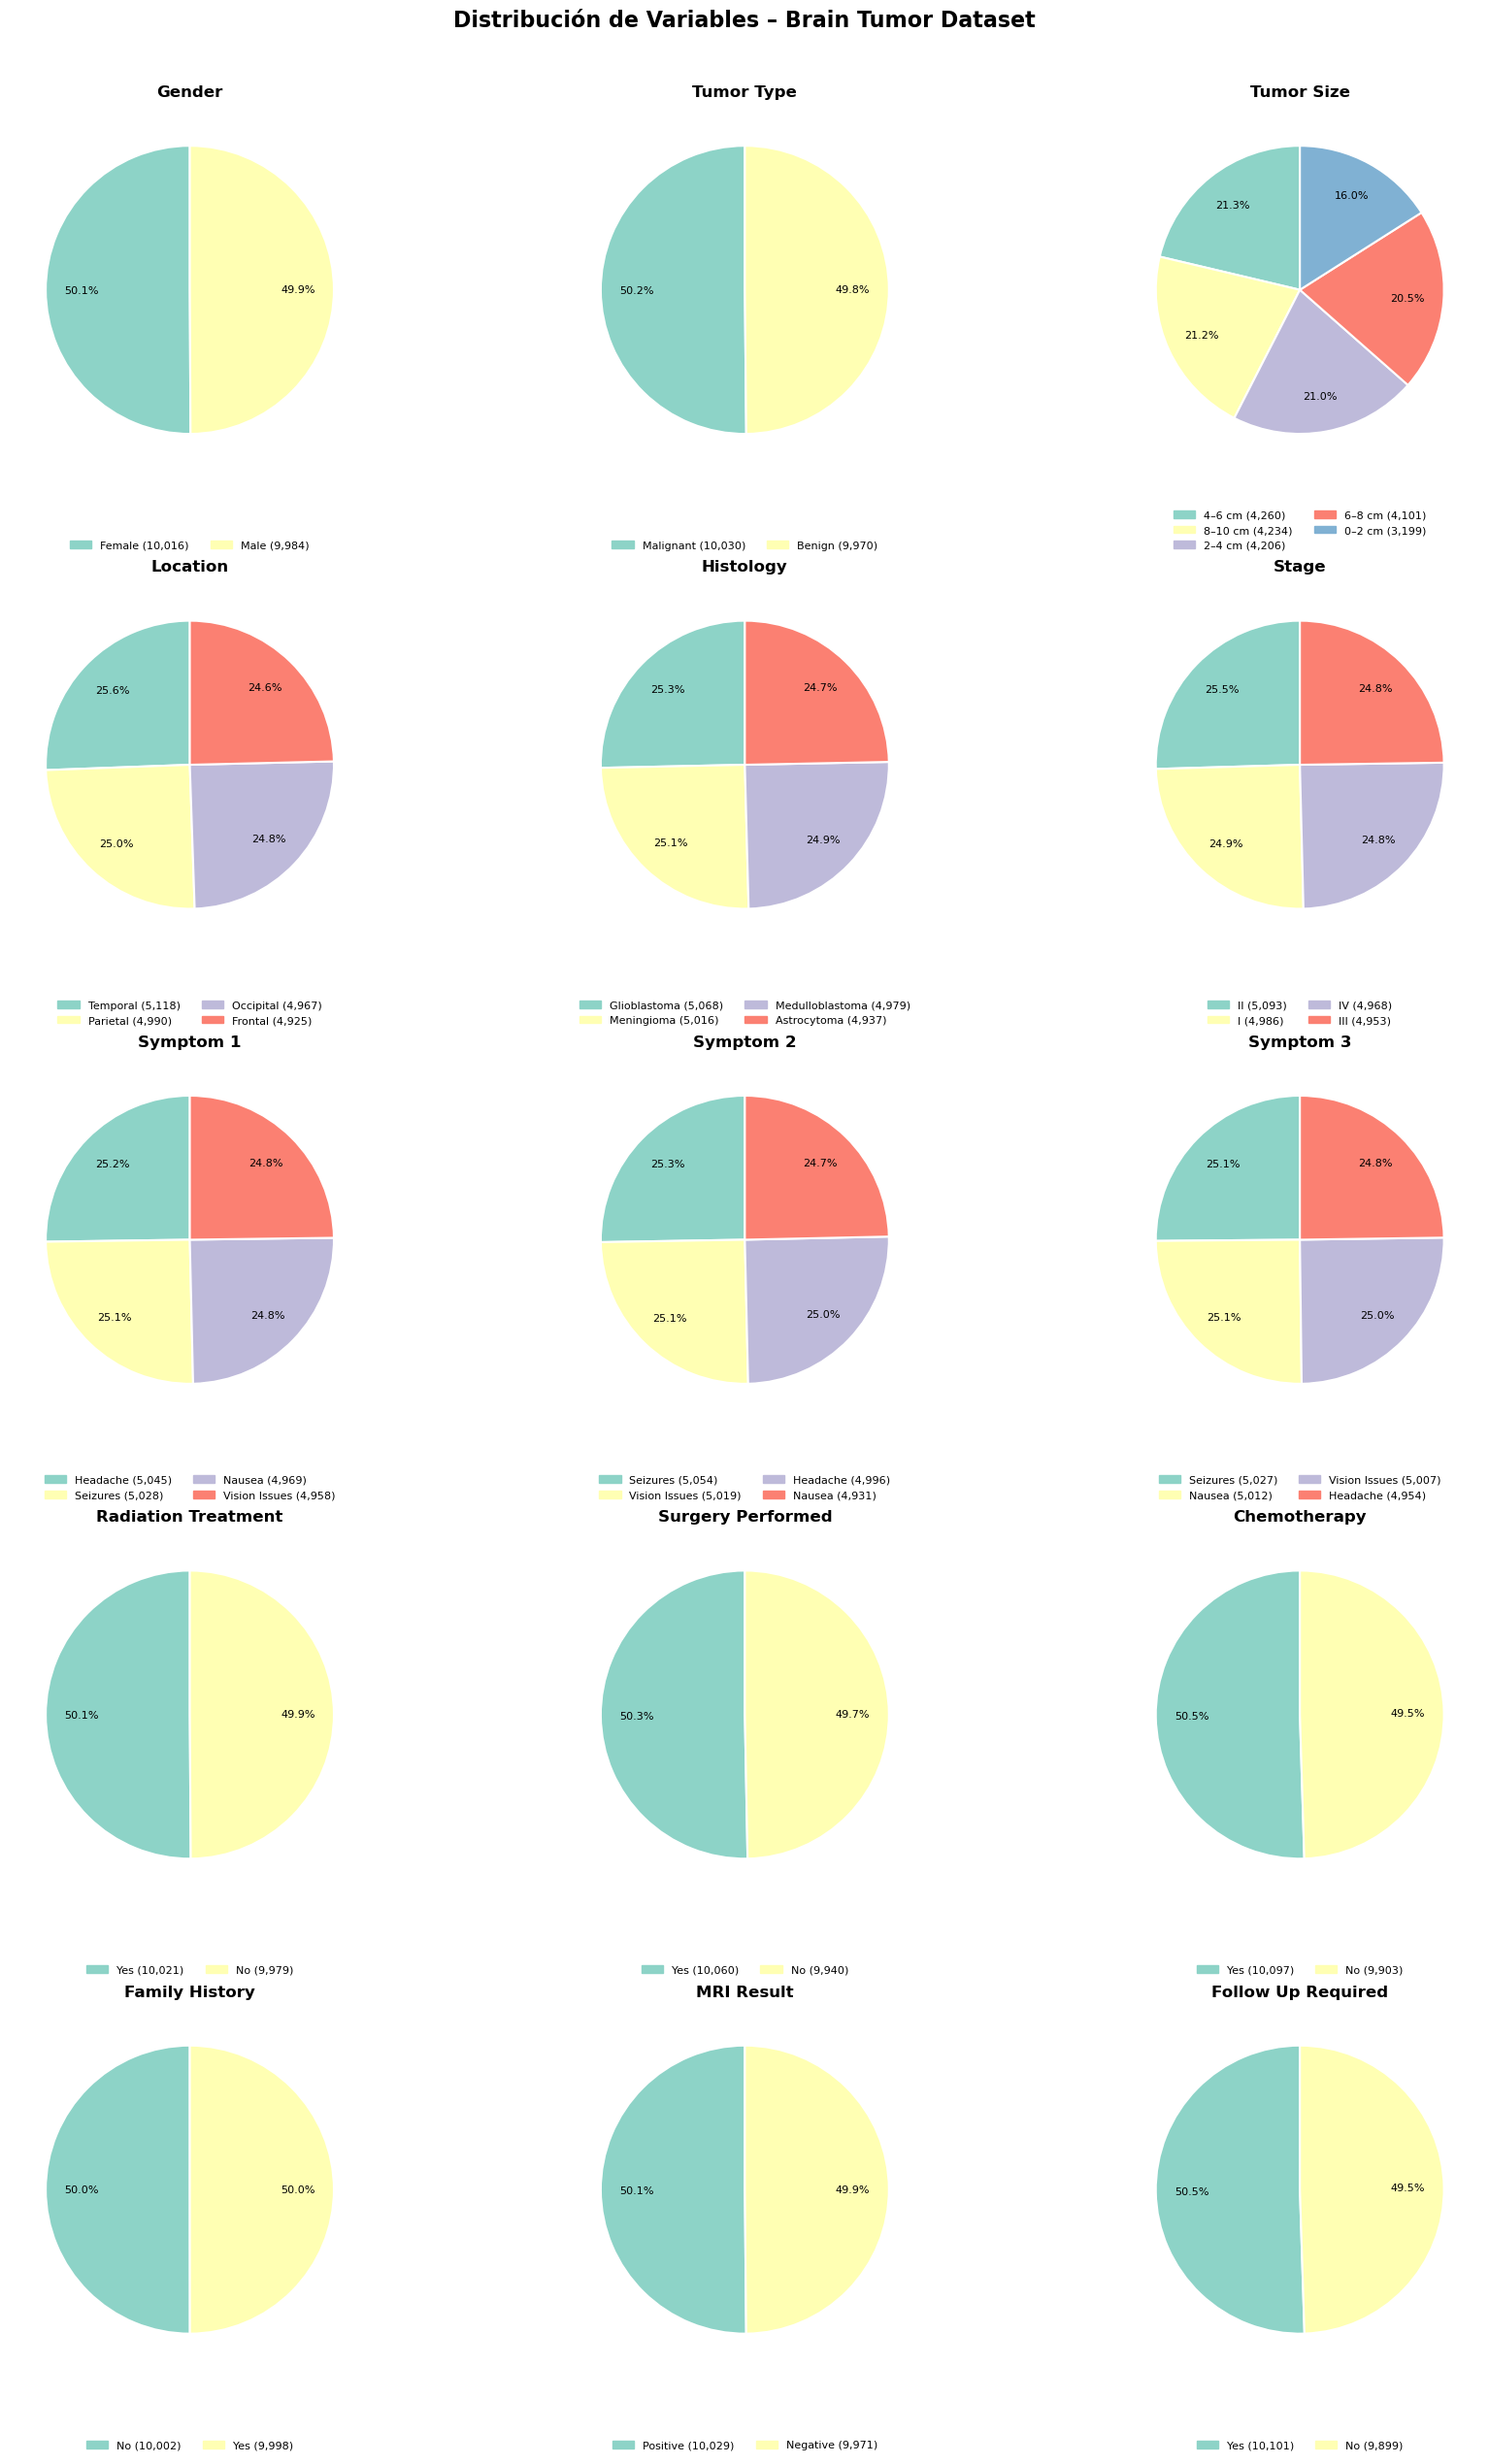

Gráfica guardada como 'brain_tumor_pie_charts.png'


In [14]:
# Columnas a graficar
columnas = [
    "Gender", "Tumor_Type", "Tumor_Size", "Location", "Histology",
    "Stage", "Symptom_1", "Symptom_2", "Symptom_3", "Radiation_Treatment",
    "Surgery_Performed", "Chemotherapy", "Family_History", "MRI_Result",
    "Follow_Up_Required"
]

# Tumor_Size es numérica → la convertimos a rangos (bins)
data["Tumor_Size"] = pd.cut(
    data["Tumor_Size"],
    bins=[0, 2, 4, 6, 8, 10],
    labels=["0–2 cm", "2–4 cm", "4–6 cm", "6–8 cm", "8–10 cm"]
)

# Paleta de colores
colores = plt.cm.Set3.colors

# Configurar grid de subplots (3 columnas)
n_cols = 3
n_rows = -(-len(columnas) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(columnas):
    ax = axes[i]
    conteo = data[col].value_counts()
    total = conteo.sum()

    wedges, texts, autotexts = ax.pie(
        conteo,
        labels=None,
        autopct="%1.1f%%",
        startangle=90,
        colors=colores[:len(conteo)],
        pctdistance=0.75,
        wedgeprops=dict(edgecolor="white", linewidth=1.5)
    )

    for at in autotexts:
        at.set_fontsize(8)
        at.set_color("black")

    # Leyenda con conteo
    leyendas = [
        mpatches.Patch(color=colores[j], label=f"{cat} ({v:,})")
        for j, (cat, v) in enumerate(conteo.items())
    ]
    ax.legend(
        handles=leyendas,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.25),
        fontsize=8,
        ncol=2,
        frameon=False
    )

    ax.set_title(col.replace("_", " "), fontsize=12, fontweight="bold", pad=10)

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribución de Variables – Brain Tumor Dataset", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("brain_tumor_pie_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada como 'brain_tumor_pie_charts.png'")

## Definimos X y Y

In [22]:
X = data.drop('Tumor_Type', axis=1)
y = data['Tumor_Type']

# P(y=1 | x=1) donde y=1 significa que es un tumor maligno

In [23]:
y = (data['Tumor_Type'] == 'Malignant').astype(int)
print(y.value_counts())

Tumor_Type
1    10030
0     9970
Name: count, dtype: int64


In [36]:
# para Stage, lo transformamos a num
categories=['I', 'II', 'III', 'IV', 'V']
num_var= OrdinalEncoder(categories=categories)

#Columnas
bool_cols = ['Gender','Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'MRI_Result', 'Follow_Up_Required', 'Gender']
num_cols = ['Age', 'Tumor_Size', 'Tumor_Growth_Rate']
cat_cols = ['Location', 'Histology']

In [37]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('bool', OneHotEncoder(), bool_cols),
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols),]) #Stage ya codificado pasa directo

## Pipeline

In [38]:
from sklearn.svm import SVC
model = SVC(random_state=42)
model

SVC(random_state=42)

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
     ('model', SVC(kernel= 'rbf' ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

f1_score(y_test, y_pred, pos_label='Malignant')

<>:7: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
C:\Users\range\AppData\Local\Temp\ipykernel_3836\3846108808.py:7: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ('preprocessor', preprocessor)


TypeError: 'tuple' object is not callable